# Droplet Tracking & Counting — YOLOv8 + ByteTrack

Tracks and counts droplets crossing a line using:
- **YOLOv8** with a trained model (`best.pt`)
- **ByteTrack** for tracking across frames
- **Supervision** for annotation and counting

Output: annotated video with IDs, trails, and real-time counting.

## 1. Installation

In [1]:
import sys
!{sys.executable} -m pip install -r requirements.txt --quiet
print("Dependencies installed from requirements.txt")

Dependencies installed from requirements.txt


## 2. Imports

In [2]:
from droplet_tracking.pipeline import (
    TrackingConfig,
    build_droplet_dataframe,
    create_calibration_ui,
    create_line_selector_ui,
    load_model_and_video_info,
    print_tracking_summary,
    process_tracking_video,
)

## 3. Settings  <- **edit here**

In [3]:
# --- FILES -------------------------------------------------------------
MODEL_PATH  = r"runs/droplets_v1/weights/best.pt"
VIDEO_PATH  = r"FF-I 20-100_trimmed.avi"
OUTPUT_PATH = r"FF-I 20-100_tracked.avi"
CAL_VIDEO_PATH = r"CALIB.avi"

# --- DETECTION ---------------------------------------------------------
CONF        = 0.1    # minimum confidence
IMGSZ       = 640    # inference image size

# --- BYTETRACK ---------------------------------------------------------
TRACK_THRESH = 0.25  # tracker activation threshold
TRACK_BUFFER = 30    # frames to keep lost tracks
MATCH_THRESH = 0.80  # IoU matching threshold
FRAME_RATE   = 25    # video fps
MIN_FRAMES   = 2     # consecutive frames to confirm a track

tracking_config = TrackingConfig(
    conf=CONF,
    imgsz=IMGSZ,
    track_thresh=TRACK_THRESH,
    track_buffer=TRACK_BUFFER,
    match_thresh=MATCH_THRESH,
    frame_rate=FRAME_RATE,
    min_frames=MIN_FRAMES,
    line_margin_px=2.0,
)

print("Settings loaded")
print(tracking_config)

Settings loaded
TrackingConfig(conf=0.1, imgsz=640, track_thresh=0.25, track_buffer=30, match_thresh=0.8, frame_rate=25, min_frames=2, line_margin_px=2.0)


## 4. Load model and inspect video

In [4]:
model, video_info = load_model_and_video_info(MODEL_PATH, VIDEO_PATH)

Model      : runs/droplets_v1/weights/best.pt
Video      : FF-I 20-100_trimmed.avi
Resolution : 640x480
FPS        : 180
Frames     : 901
Duration   : 5.0s


## 5. Calibration — reference measurement

Click on **two points** over the image scale bar to define how many µm correspond to N pixels.

The result (`um_per_px`) is automatically used to calculate the real droplet diameter in the video.

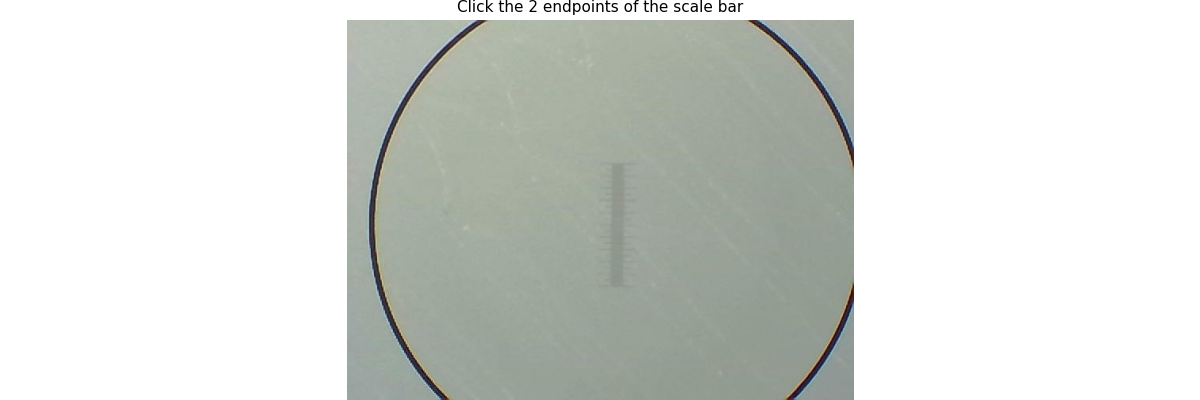

Select 2 points and click Confirm in the widget.


In [ ]:
%matplotlib widget
calibration_state = create_calibration_ui(CAL_VIDEO_PATH, default_reference_um=100.0)
print("Select 2 points and click Confirm in the widget.")

## 6. Define counting line

Display a frame to help position the line.

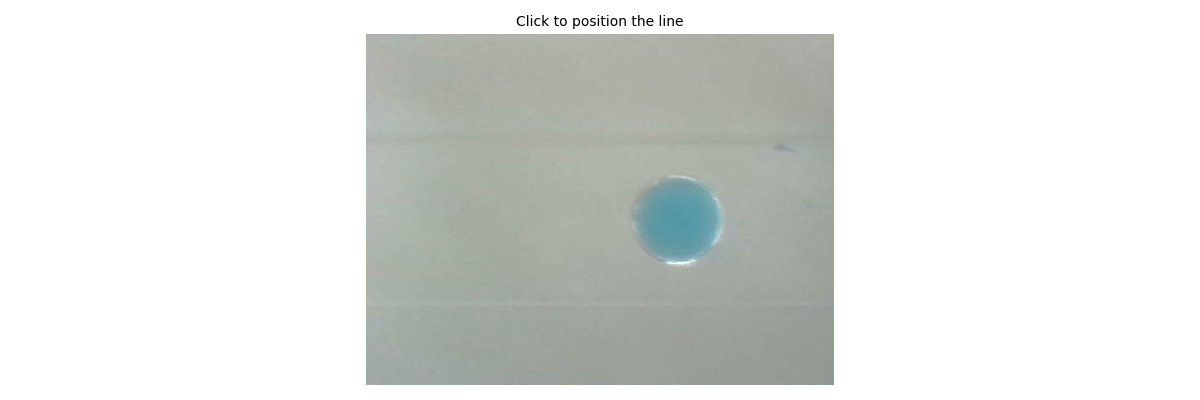

Click on the image, adjust orientation/length, then click Confirm.


In [ ]:
%matplotlib widget
line_state = create_line_selector_ui(VIDEO_PATH)
print("Click on the image, adjust orientation/length, then click Confirm.")

## 7. Process full video with tracking and counting

In [7]:
if line_state.get("line_start") is None or line_state.get("line_end") is None:
    raise ValueError("Counting line not confirmed. Run the previous cell and click Confirm.")

result = process_tracking_video(
    model=model,
    video_info=video_info,
    video_path=VIDEO_PATH,
    output_path=OUTPUT_PATH,
    line_start=line_state["line_start"],
    line_end=line_state["line_end"],
    config=tracking_config,
)

line_touch_records = result["line_touch_records"]


Video saved to: FF-I 20-100_tracked.avi
Total droplets : 5
Diameters measured on the line : 5


## 8. Final summary

In [8]:
um_per_px = calibration_state.get("um_per_px")

df_line = print_tracking_summary(
    line_touch_records=line_touch_records,
    um_per_px=um_per_px,
    video_info=video_info,
    total_count=result["in_count"],
    video_path=VIDEO_PATH,
    output_path=OUTPUT_PATH,
    window_s=10.0,
)

  EXPERIMENT SUMMARY
  Video          : FF-I 20-100_trimmed.avi
  Duration       : 5.0 s
  Droplets IN    : 5
  Rate           : 1.00 droplets/s
  Frequency      : 59.9 droplets/min

  Generation frequency  (Dt = 10 s windows)
    Window   t_start     t_end   count   freq (Hz)  freq (min^-1)
  --------  --------  --------  ------  ----------  ------------
         0        0s       10s       5       0.500         30.00

  Freq mean      : 0.500 Hz  (30.00 min^-1)
  Freq SD        : 0.000 Hz
  Freq CV        : 0.0 %

  Diameters & aspect ratio at line crossing  [um]
    frame     id        dx        dy    d_mean      Psi
  -------  -----  --------  --------  --------  -------
       46  #1        796.6     809.5     803.0    0.984
      252  #2        798.6     805.2     801.9    0.992
      457  #3        797.4     804.0     800.7    0.992
      660  #4        796.3     802.6     799.5    0.992
      862  #5        794.4     803.3     798.8    0.989

                        dx        d

In [9]:
df_drops = build_droplet_dataframe(line_touch_records, um_per_px=um_per_px)
df_drops

,frame,track_id,dx_px,dy_px,d_px,aspect_ratio,dx_um,dy_um,d_um
0,46,1,123.50,125.49,124.49,0.9841,796.62,809.46,803.01
1,252,2,123.81,124.83,124.32,0.9918,798.62,805.20,801.91
2,457,3,123.61,124.64,124.13,0.9918,797.33,803.98,800.69
3,660,4,123.46,124.43,123.94,0.9922,796.37,802.62,799.46
4,862,5,123.15,124.54,123.84,0.9889,794.37,803.33,798.82
